In [1]:
import os
import json
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking, BatchNormalization, Bidirectional, MaxPooling1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from keras.utils import plot_model


2024-12-17 01:59:29.865927: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-17 01:59:30.516784: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# check if the gpu support available
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2024-12-17 01:59:34.231388: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-17 01:59:34.255077: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-17 01:59:34.255247: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [3]:
data_directory = '../all_outputs/output_holistic_pickle_wlasl2/'
meta_data_file = '../WLASL_v0.3.json'

In [4]:
content = json.load(open(meta_data_file))
filenames = set(os.listdir(data_directory))

In [5]:
# Shape of dataset (videos, frames, landmarks_fflattened)
# Number of videos = number of files in data_directory
# We take 24 frames from each video
# 

all_data = []

In [7]:
with open(data_directory + "09956.pkl", 'rb') as f:
        land_marks = pickle.load(f)
        # print the format of read data
        print(land_marks[0].keys())
        print(len(land_marks[40]['left_hand_landmarks']))

dict_keys(['pose_landmarks', 'face_landmarks', 'left_hand_landmarks', 'right_hand_landmarks'])


IndexError: list index out of range

In [8]:
# Define indices for points of interest
pose_indices = [0, 11, 12, 13, 14, 15, 16, 23, 24]
hand_indices = [0, 1, 3, 4, 6, 8, 10, 12, 14, 16, 18, 20]

In [9]:

def load_landmarks(content, filenames, data_directory, num_frames):
    
    
    # Prepare storage for data and labels
    video_data = []
    labels = []
    
    for entry in content:
        instances = entry['instances']
        gloss = entry['gloss']  # label for current video

        for inst in instances:
            file_id = inst['video_id']
            if file_id + '.pkl' in filenames:
                with open(os.path.join(data_directory, file_id + '.pkl'), 'rb') as f:
                    landmarks = pickle.load(f)
                    
                    # Prepare frame storage for each video with fixed number of frames
                    frames = []

                    # Get frame sampling step (skip frames if necessary)
                    total_frames = len(landmarks)
                    step = max(1, total_frames // num_frames)
                    
                    # Process frames
                    for i in range(num_frames):
                        frame_index = i * step if total_frames >= num_frames else i
                        
                        if frame_index < total_frames:
                            frame = landmarks[frame_index]
                        else:
                            frame = None
                        
                        # Extract and flatten required points
                        pose_points = frame['pose_landmarks'] if frame and frame['pose_landmarks'] else [None] * 33
                        left_hand_points = frame['left_hand_landmarks'] if frame and frame['left_hand_landmarks'] else [None] * 21
                        right_hand_points = frame['right_hand_landmarks'] if frame and frame['right_hand_landmarks'] else [None] * 21
                        
                        # Collect only specified indices and flatten them
                        extracted_points = []

                        # Collect pose points first
                        for idx in pose_indices:
                            point = pose_points[idx] if pose_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])
                        
                        # print(left_hand_points)
                        for idx in hand_indices:
                            point = left_hand_points[idx] if left_hand_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])

                        # Collect right hand points
                        for idx in hand_indices:
                            point = right_hand_points[idx] if right_hand_points[idx] is not None else {'x': 0, 'y': 0}
                            extracted_points.extend([point['x'], point['y']])
                        
                        frames.append(extracted_points)
                    
                    # Add the processed video frames to the main array
                    video_data.append(frames)
                    labels.append(gloss)

    # Convert to numpy arrays
    video_data = np.array(video_data)
    labels = np.array(labels)
    
    return video_data, labels

# Example usage
num_frames = 30  # Desired fixed number of frames per video

video_data, labels = load_landmarks(content, filenames, data_directory, num_frames)

# `video_data` has shape (number of videos, num_frames, number of points*2) where points*2 is the flattened landmark count
# `labels` contains the labels for each video


In [10]:
NUM_CLASSES = len(set(labels))
NUM_CLASSES

20

In [11]:
# Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_one_hot = to_categorical(labels_encoded, num_classes=NUM_CLASSES)

# Split dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(video_data, labels_one_hot, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)



In [12]:
# print train, val, test shapes
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(170, 30, 66) (170, 20)
(36, 30, 66) (36, 20)
(37, 30, 66) (37, 20)


In [ ]:
# input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)

In [17]:
# Parameters
LSTM_HIDDEN_DIM = 256
DENSE_UNITS = 128  # Units for additional dense layers

# Model Definition
model = Sequential([
    # Dropout Layer for regularization
    Dropout(0.2, input_shape=(num_frames, len(pose_indices) * 2 + len(hand_indices) * 2 * 2)),

    # Batch Normalization
    BatchNormalization(),

    # Three layers of BiLSTM with hidden dimension 256
    Bidirectional(LSTM(LSTM_HIDDEN_DIM, return_sequences=True)),
    Bidirectional(LSTM(LSTM_HIDDEN_DIM, return_sequences=True)),
    Bidirectional(LSTM(LSTM_HIDDEN_DIM, return_sequences=True)),  # Additional BiLSTM layer

    # Global Max Pooling to get a single vector representation
    GlobalMaxPooling1D(),

    # Three additional dense layers
    Dense(DENSE_UNITS, activation='relu'),
    Dense(DENSE_UNITS, activation='relu'),
    Dense(DENSE_UNITS, activation='relu'),

    # Output Layer with Softmax for classification
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile the Model
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print Model Summary
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_1 (Dropout)         (None, 30, 66)            0         
                                                                 
 batch_normalization_1 (Bat  (None, 30, 66)            264       
 chNormalization)                                                
                                                                 
 bidirectional_3 (Bidirecti  (None, 30, 512)           661504    
 onal)                                                           
                                                                 
 bidirectional_4 (Bidirecti  (None, 30, 512)           1574912   
 onal)                                                           
                                                                 
 bidirectional_5 (Bidirecti  (None, 30, 512)           1574912   
 onal)                                                

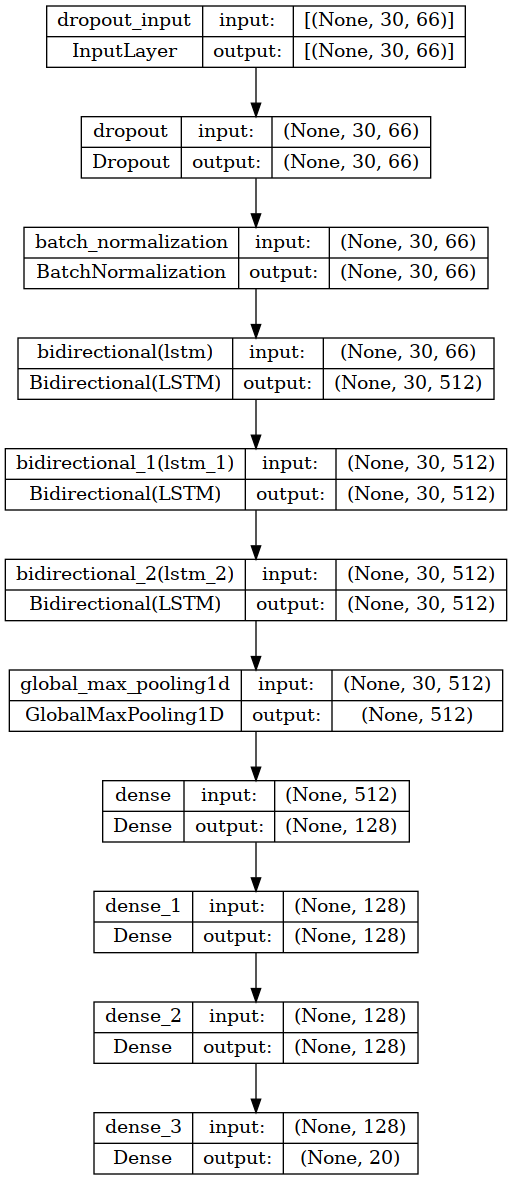

In [14]:
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [18]:
# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)


# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")




# Save label encoder and model if needed
# joblib.dump(label_encoder, 'label_encoder.pkl')
# model.save('lstm_landmark_model.h5')

Epoch 1/50
6/6 [==============================] - 9s 325ms/step - loss: 2.9732 - accuracy: 0.0706 - val_loss: 3.0193 - val_accuracy: 0.0278
Epoch 2/50
6/6 [==============================] - 0s 27ms/step - loss: 2.8360 - accuracy: 0.0882 - val_loss: 3.1381 - val_accuracy: 0.0278
Epoch 3/50
6/6 [==============================] - 0s 24ms/step - loss: 2.6987 - accuracy: 0.1294 - val_loss: 3.0379 - val_accuracy: 0.0278
Epoch 4/50
6/6 [==============================] - 0s 25ms/step - loss: 2.5812 - accuracy: 0.1529 - val_loss: 3.0919 - val_accuracy: 0.0278
Epoch 5/50
6/6 [==============================] - 0s 24ms/step - loss: 2.5093 - accuracy: 0.1882 - val_loss: 3.0477 - val_accuracy: 0.0556
Epoch 6/50
6/6 [==============================] - 0s 25ms/step - loss: 2.4098 - accuracy: 0.2353 - val_loss: 2.8473 - val_accuracy: 0.0278
Epoch 7/50
6/6 [==============================] - 0s 25ms/step - loss: 2.2764 - accuracy: 0.2353 - val_loss: 2.7998 - val_accuracy: 0.1389
Epoch 8/50
6/6 [==========

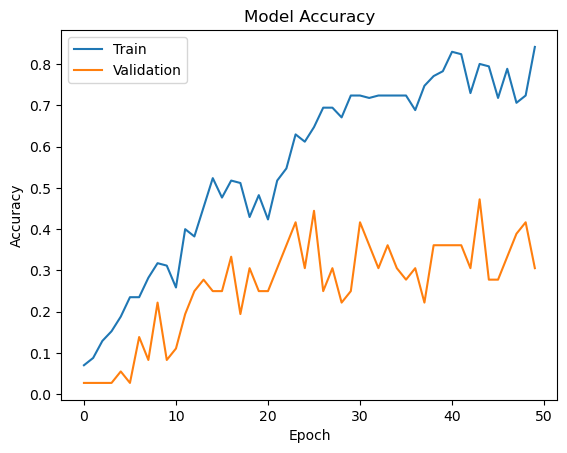

In [19]:

# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
save_plt = plt
plt.show()



FileNotFoundError: [Errno 2] No such file or directory: '..Results/exp_3/accuracy.png'

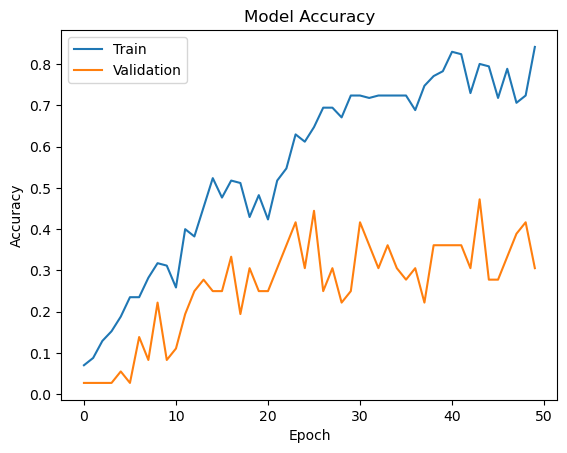

In [ ]:
exp_number = 3
description = "Experiment with WLASL dataset with Top most 20 classes. About 250 videos. This should be compared with the results in exp 4. which is planned to be the first transfer leaning approach"

# create folder to store results and store results if folder is already there, show error
if not os.path.exists('../Results/exp_' + str(exp_number)):
    os.makedirs('../Results/exp_' + str(exp_number))

    with open('../Results/exp_' + str(exp_number) + '/description.txt', 'w') as f:
        f.write(description)

    # also save plots
        plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.savefig('../Results/exp_' + str(exp_number) + '/accuracy.png')


else:
    print("Folder already exists")


In [ ]:

# Define model parameters
input_dim = 512  # Adjust this based on your input feature size
hidden_dim = 256
output_dim = 10  # Adjust this based on the number of sign language classes

# Define the model architecture
class SignLanguageModel(tf.keras.Model):
    def __init__(self):
        super(SignLanguageModel, self).__init__()
        
        # Batch normalization layer
        self.batch_norm = tf.keras.layers.BatchNormalization()
        
        # Projection to lower dimension
        self.projection_layer = tf.keras.layers.Dense(input_dim, activation='relu')
        
        # Dropout layer
        self.dropout = tf.keras.layers.Dropout(0.2)
        
        # Two-layer BiLSTM
        self.bi_lstm1 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hidden_dim, return_sequences=True))
        self.bi_lstm2 = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(hidden_dim, return_sequences=True))
        
        # Max pooling layer
        self.max_pooling = tf.keras.layers.GlobalMaxPooling1D()
        
        # Output linear layer
        self.output_layer = tf.keras.layers.Dense(output_dim)
        
        # Softmax for classification
        self.softmax = tf.keras.layers.Softmax()

    def call(self, inputs, training=False):
        # Normalize inputs
        x = self.batch_norm(inputs, training=training)
        
        # Project to lower dimension
        x = self.projection_layer(x)
        
        # Apply dropout
        x = self.dropout(x, training=training)
        
        # BiLSTM layers
        x = self.bi_lstm1(x)
        x = self.bi_lstm2(x)
        
        # Max pooling
        x = self.max_pooling(x)
        
        # Final linear layer and softmax
        x = self.output_layer(x)
        x = self.softmax(x)
        
        return x

# Instantiate the model
model = SignLanguageModel()

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# Example usage: Assuming `train_dataset` is a tf.data.Dataset containing (features, labels)
# model.fit(train_dataset, epochs=10, batch_size=512)
